## Import Statements


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("911.csv")
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lat        99492 non-null  float64
 1   lng        99492 non-null  float64
 2   desc       99492 non-null  object 
 3   zip        86637 non-null  float64
 4   title      99492 non-null  object 
 5   timeStamp  99492 non-null  object 
 6   twp        99449 non-null  object 
 7   addr       98973 non-null  object 
 8   e          99492 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 6.8+ MB


### Data Exploration


#### Getting the most calls from a zip codes


In [4]:
df["zip"].value_counts()

zip
19401.0    6979
19464.0    6643
19403.0    4854
19446.0    4748
19406.0    3174
           ... 
19119.0       1
77316.0       1
19457.0       1
19107.0       1
19127.0       1
Name: count, Length: 104, dtype: int64

#### Top Townships according to calls


In [5]:
df["twp"].value_counts()[:5]

twp
LOWER MERION    8443
ABINGTON        5977
NORRISTOWN      5890
UPPER MERION    5227
CHELTENHAM      4575
Name: count, dtype: int64

#### Creating New Columns


In [6]:
df["Reasons"] = df["title"].apply(lambda x: x.split(":")[0])
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reasons
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1,EMS
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1,EMS
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1,Fire
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1,EMS
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1,EMS


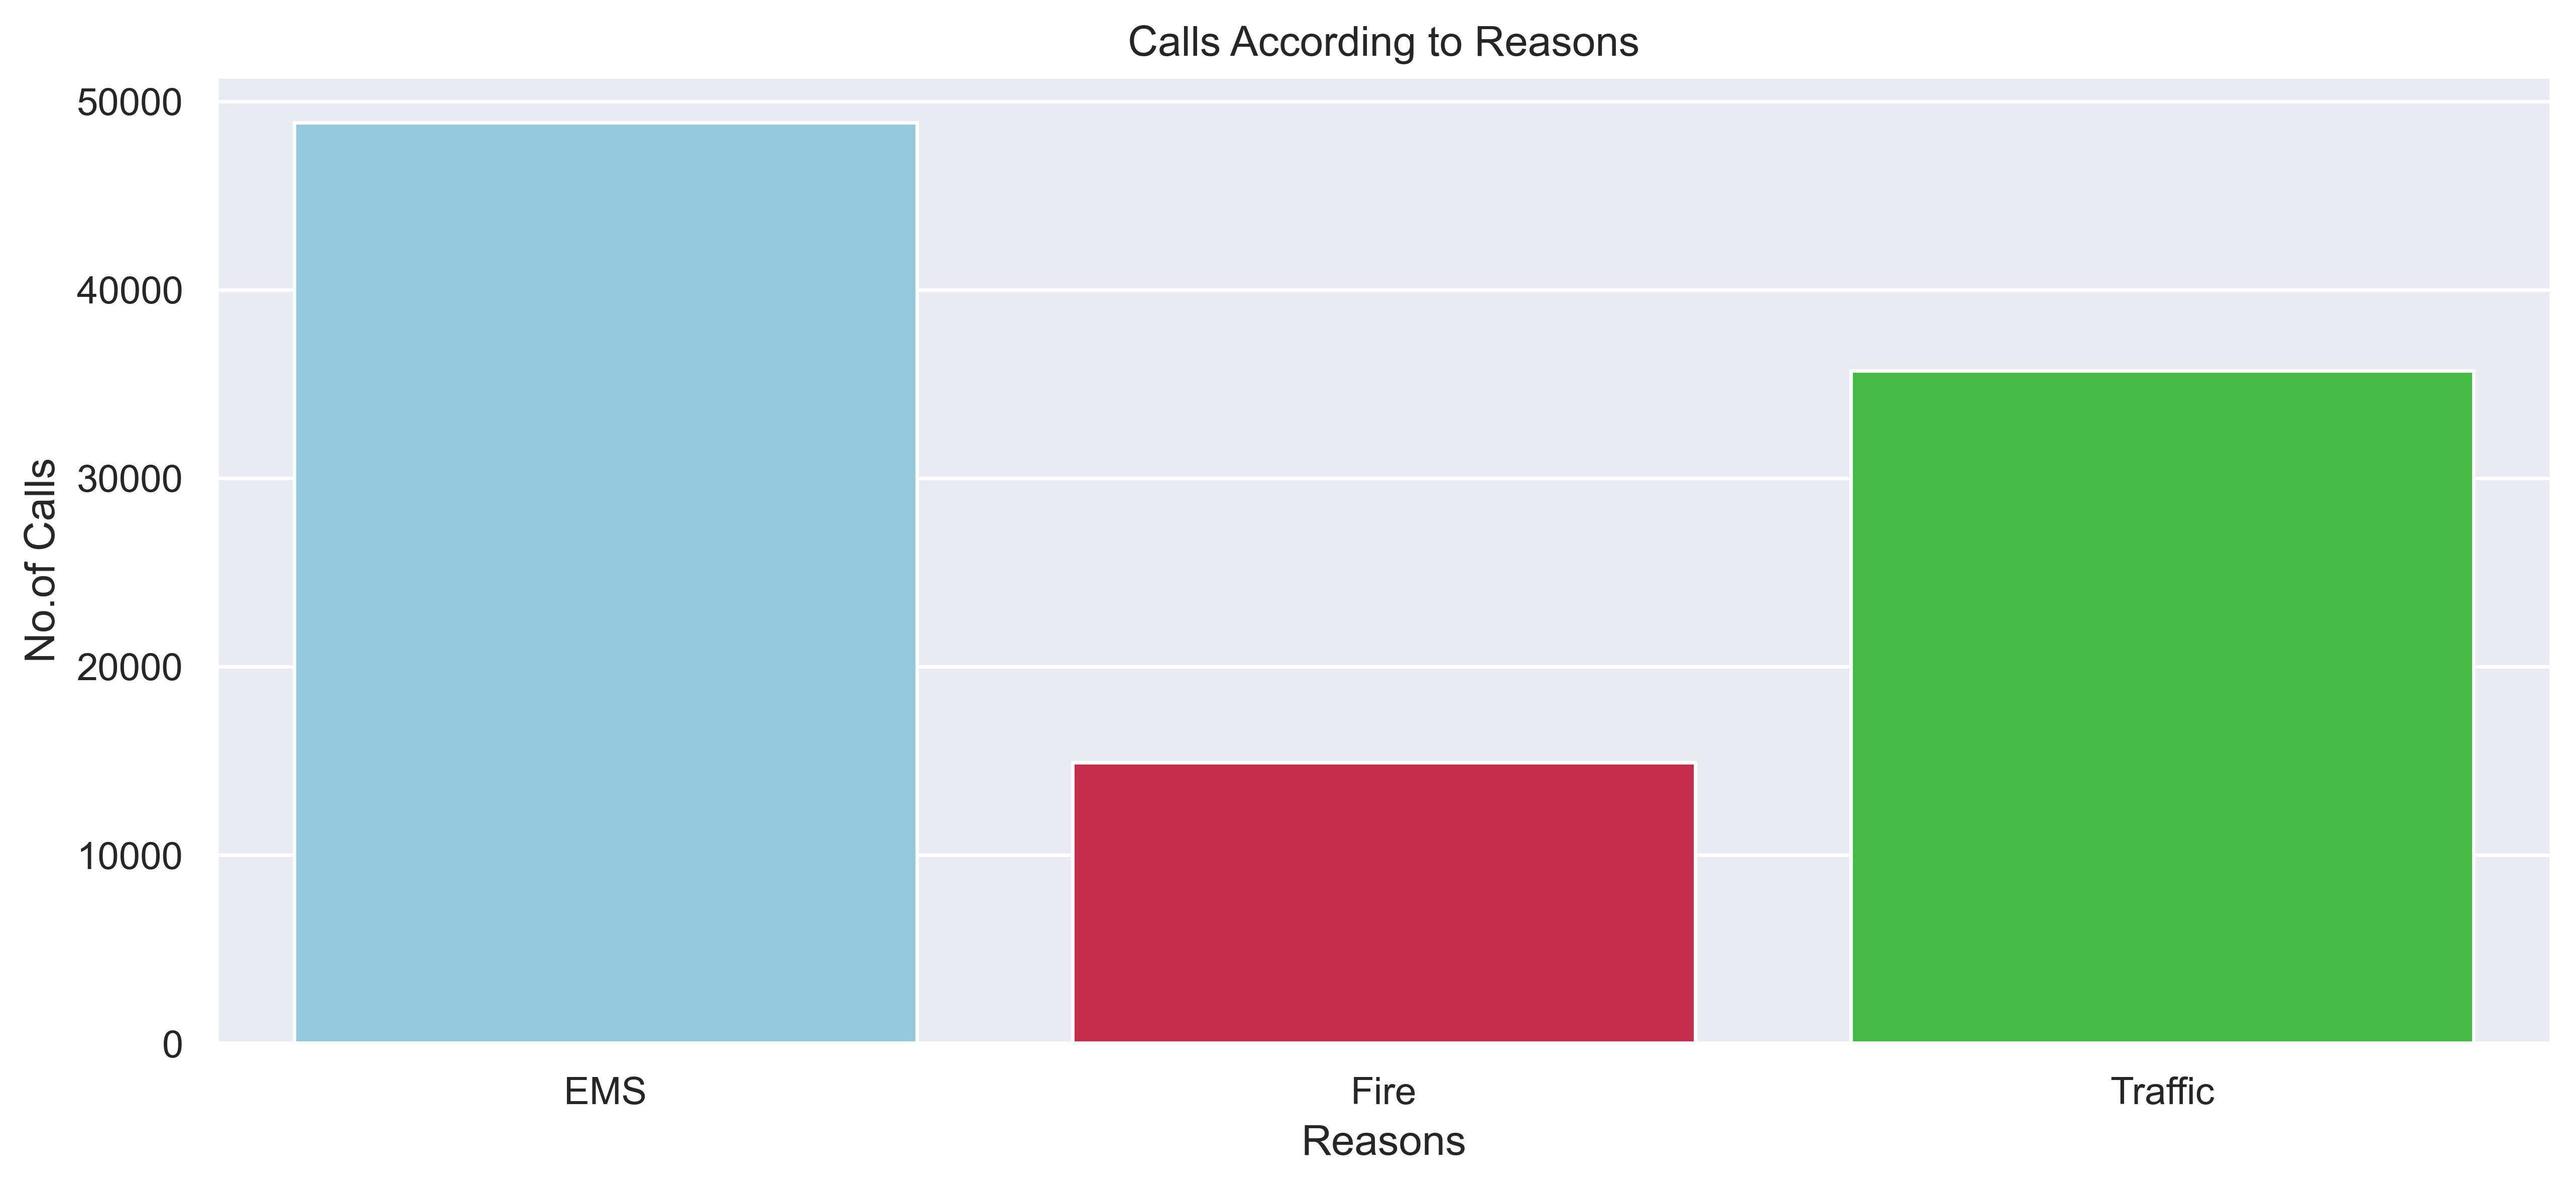

In [7]:
sns.set_theme("notebook")

plt.figure(figsize=(12, 5), dpi=500)

plt.title("Calls According to Reasons")
plt.xlabel("Reasons")
plt.ylabel("No.of Calls")


sns.countplot(
    data=df,
    x="Reasons",
    hue="Reasons",
    palette=["skyblue", "crimson", "#32CD32"],
)

plt.show()

In [8]:
df["timeStamp"] = pd.to_datetime(df["timeStamp"])

In [9]:
df["Hours"] = df["timeStamp"].apply(lambda x: x.hour)
df["Months"] = df["timeStamp"].apply(lambda x: x.month)
df["Day of Week"] = df["timeStamp"].apply(lambda x: x.dayofweek)

dmap = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thur",
    4: "Fri",
    5: "Sat",
    6: "Sun",
}

df["Day of Week"] = df["Day of Week"].map(dmap)

df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reasons,Hours,Months,Day of Week
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1,EMS,17,12,Thur
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1,EMS,17,12,Thur
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1,Fire,17,12,Thur
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1,EMS,17,12,Thur
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1,EMS,17,12,Thur


#### Visualize Calls Per Day of Week


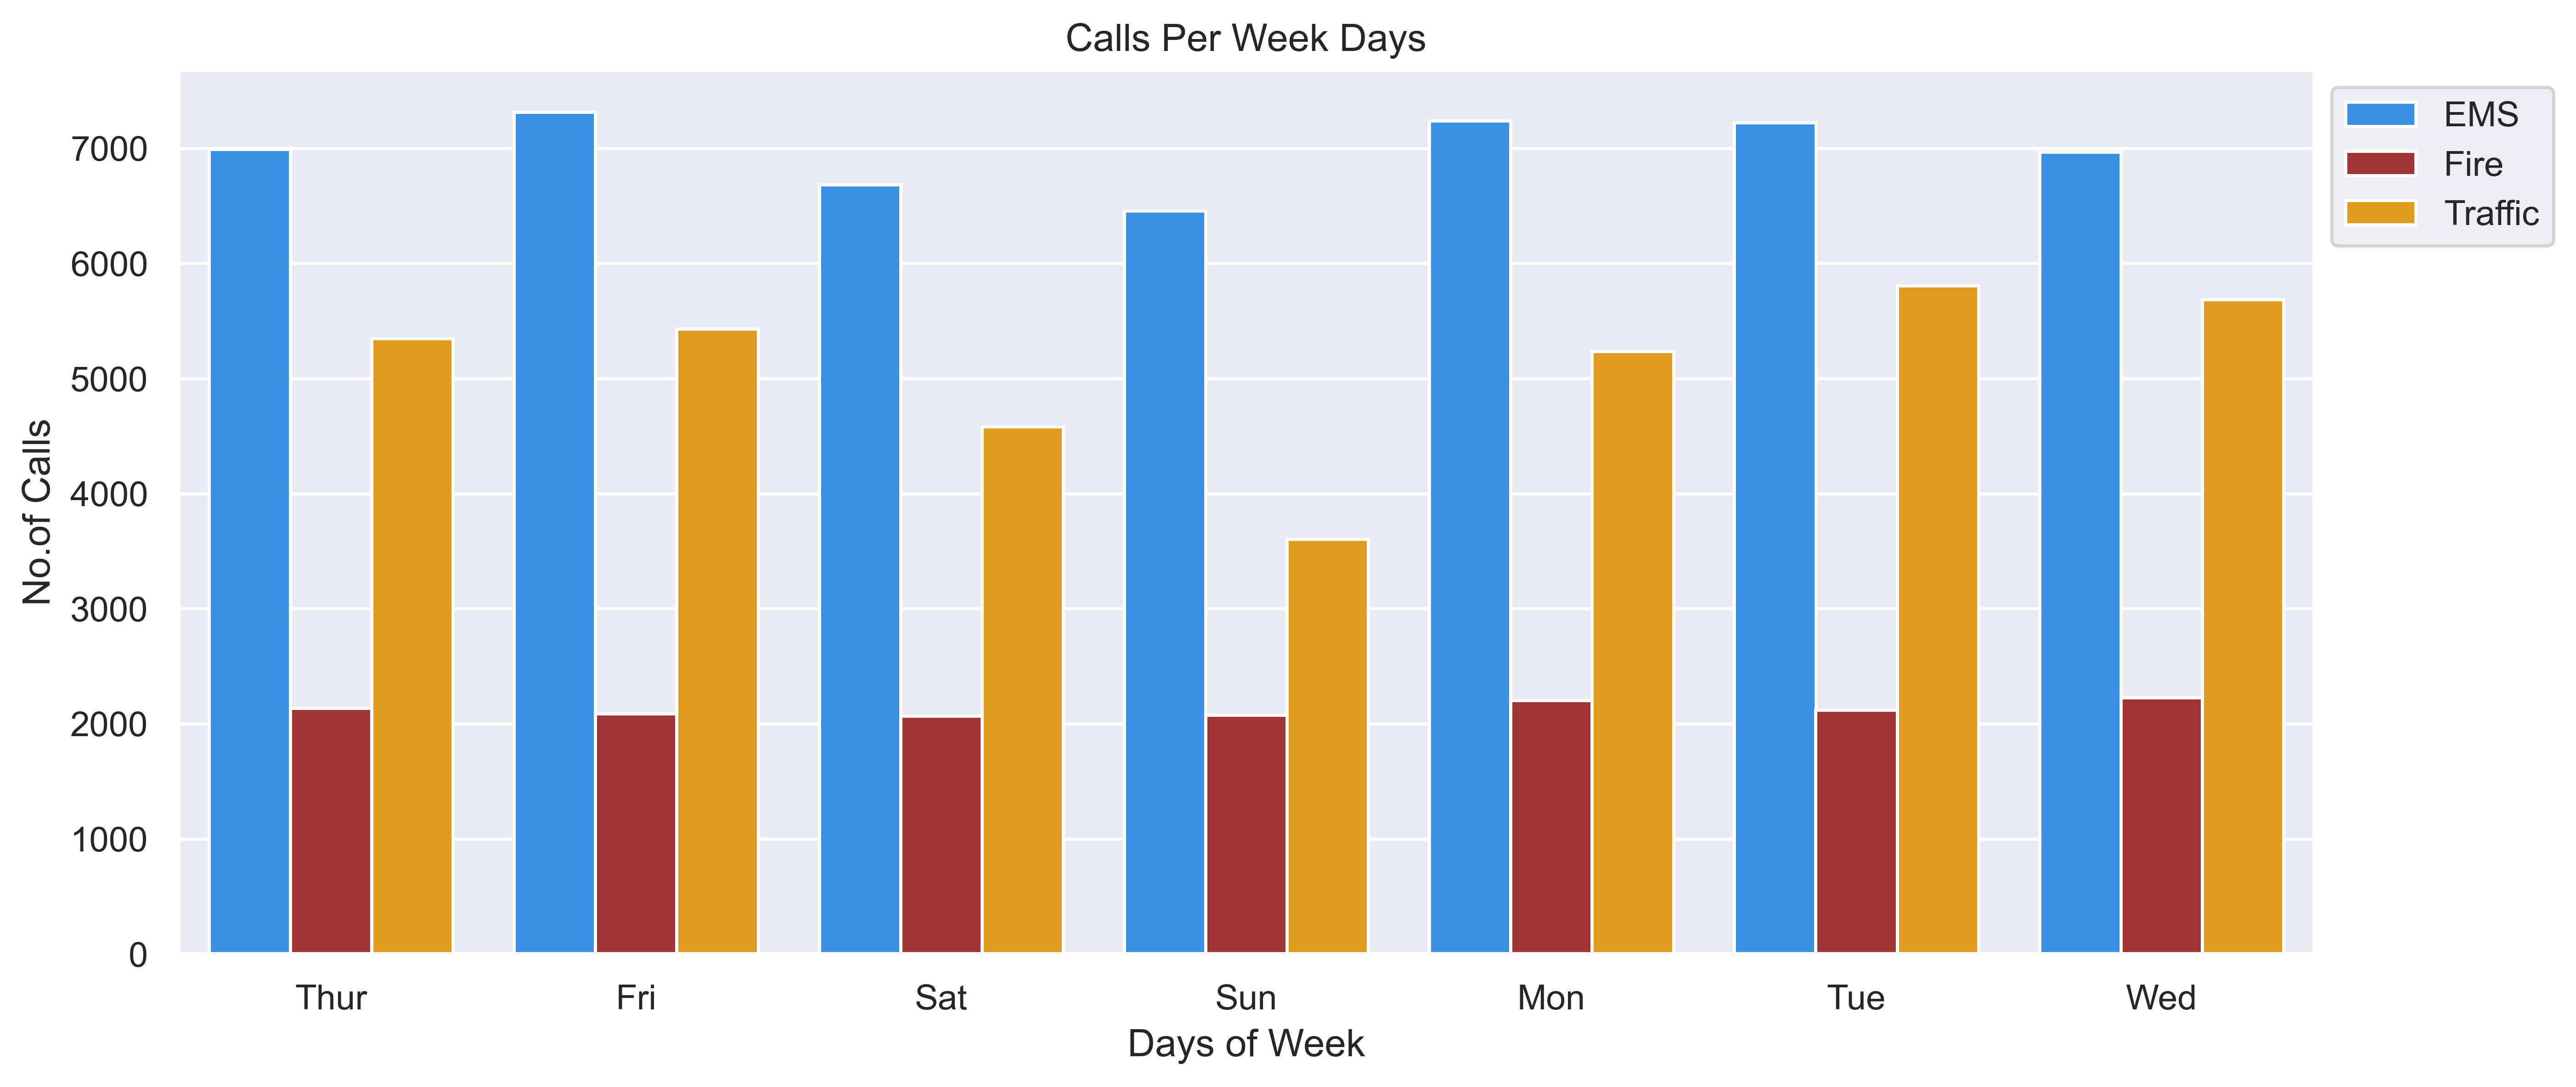

In [10]:
plt.figure(figsize=(12, 5), dpi=500)

plt.xlabel("Days of Week")
plt.ylabel("No.of Calls")
plt.title("Calls Per Week Days")

sns.set_theme("notebook")
sns.countplot(
    data=df,
    x="Day of Week",
    hue="Reasons",
    palette=["dodgerblue", "firebrick", "orange"],
)

plt.legend(loc=2, bbox_to_anchor=(1, 1))

plt.show()

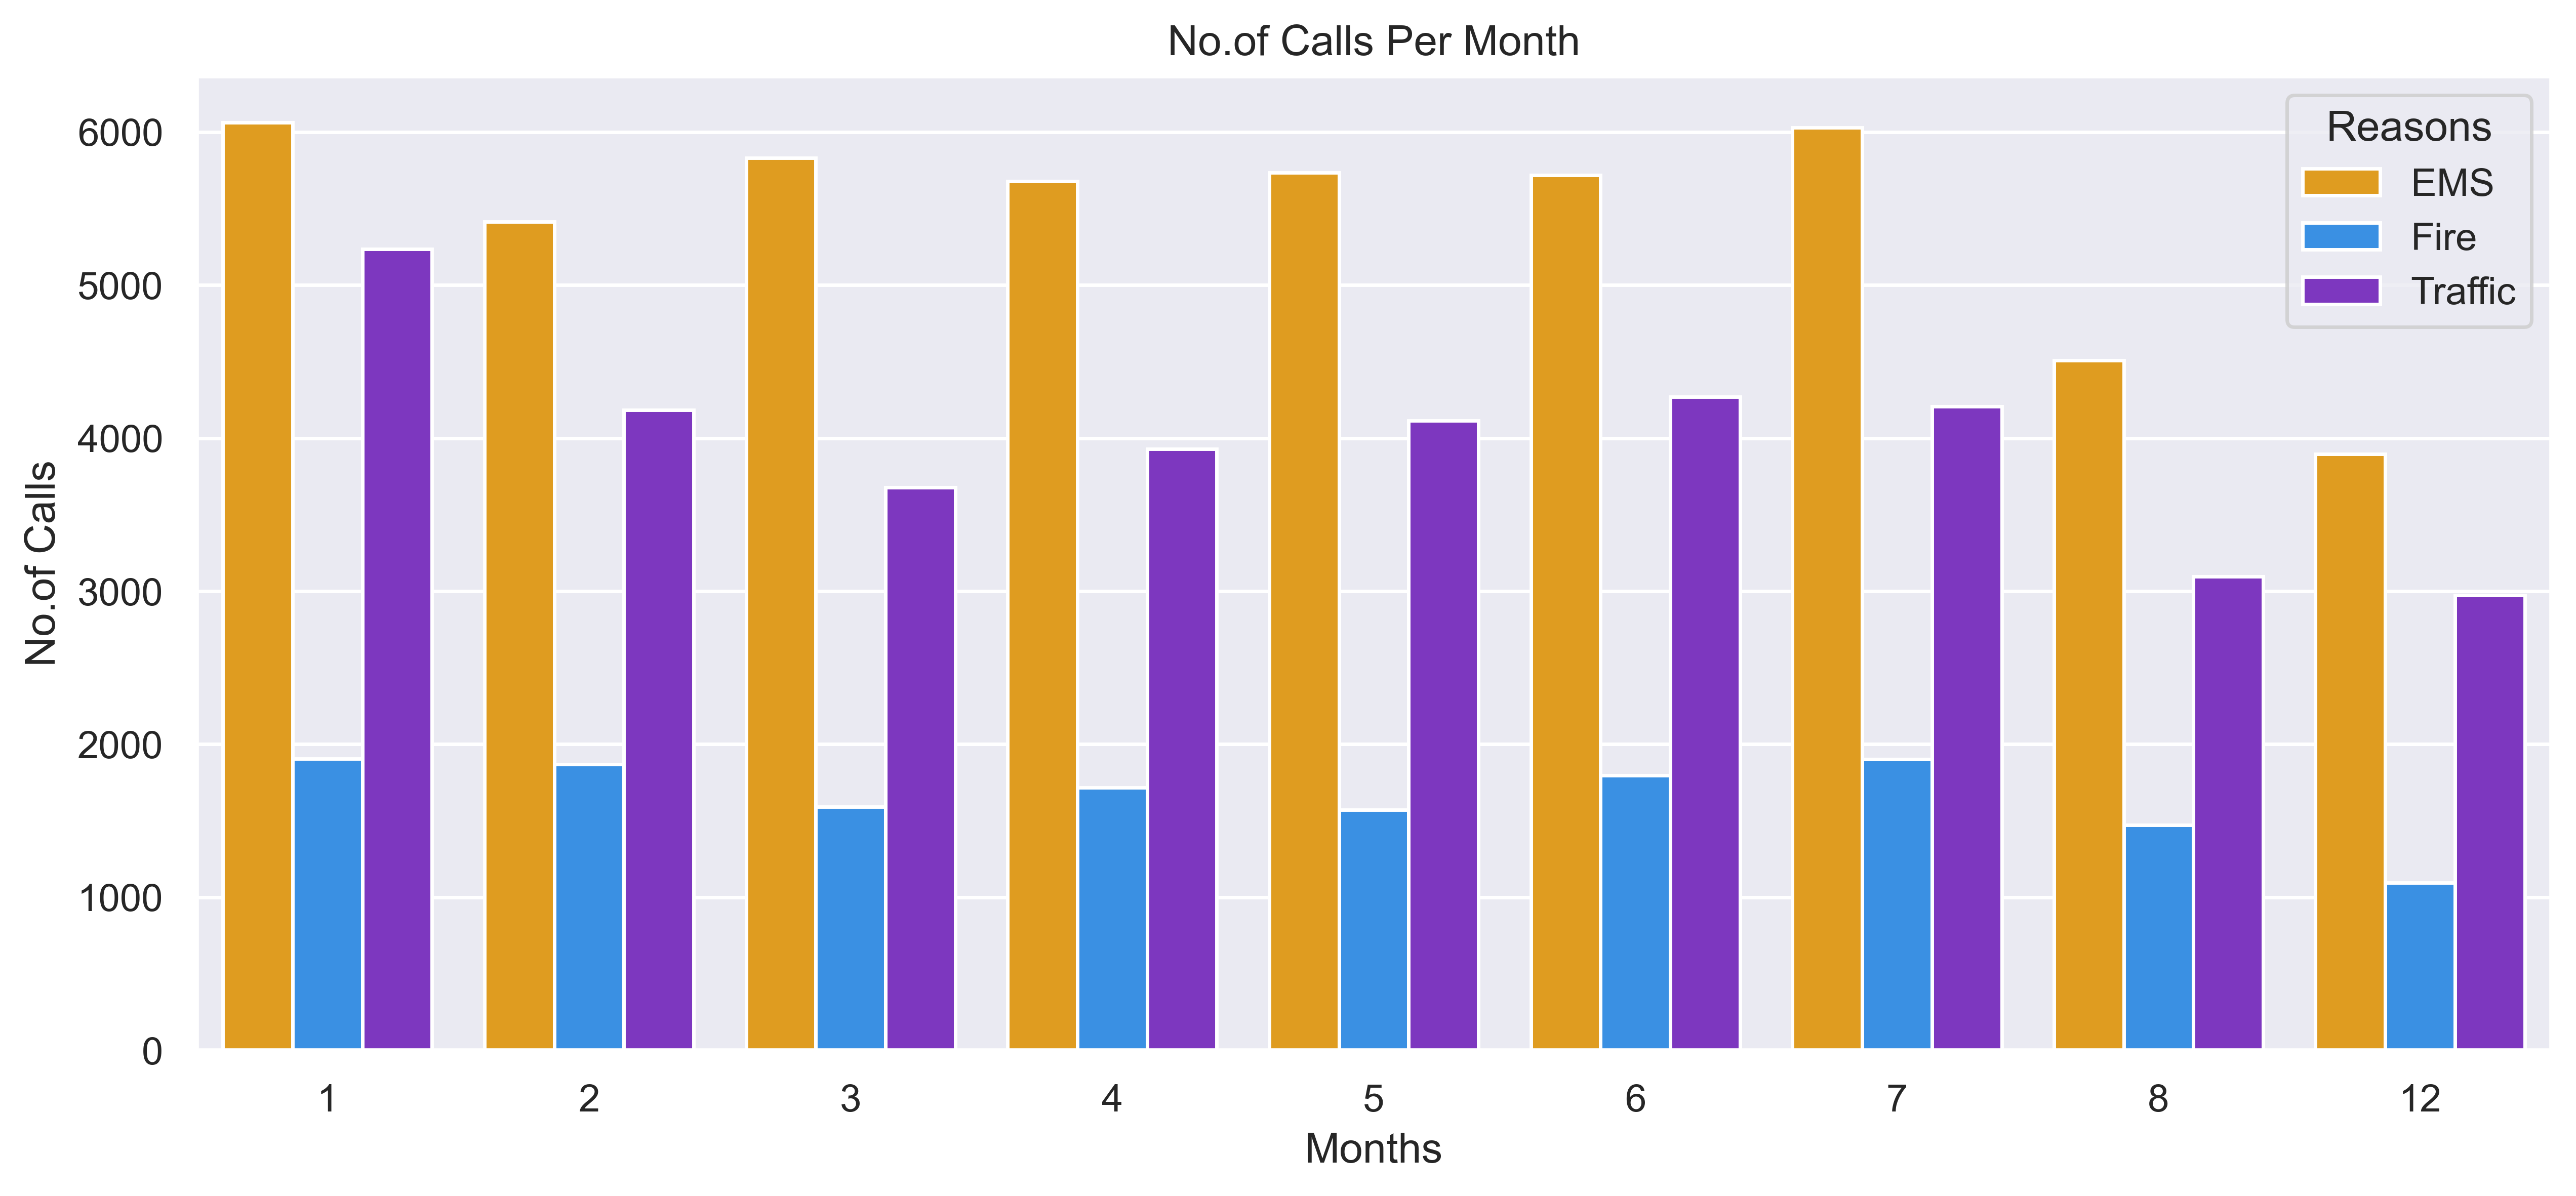

In [11]:
plt.figure(figsize=(12, 5), dpi=500)

plt.title("No.of Calls Per Month")
plt.xlabel("Months")
plt.ylabel("No.of Calls")

sns.set_theme("notebook")
sns.countplot(
    data=df,
    x="Months",
    hue="Reasons",
    palette=["orange", "dodgerblue", "#7e20d6"],
)

plt.show()

In [12]:
by_months = df.groupby("Months").count()

by_months.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reasons,Hours,Day of Week
Months,,,,,,,,,,,,
1,13205,13205,13205,11527,13205,13205,13203,13096,13205,13205,13205,13205
2,11467,11467,11467,9930,11467,11467,11465,11396,11467,11467,11467,11467
3,11101,11101,11101,9755,11101,11101,11092,11059,11101,11101,11101,11101
4,11326,11326,11326,9895,11326,11326,11323,11283,11326,11326,11326,11326
5,11423,11423,11423,9946,11423,11423,11420,11378,11423,11423,11423,11423


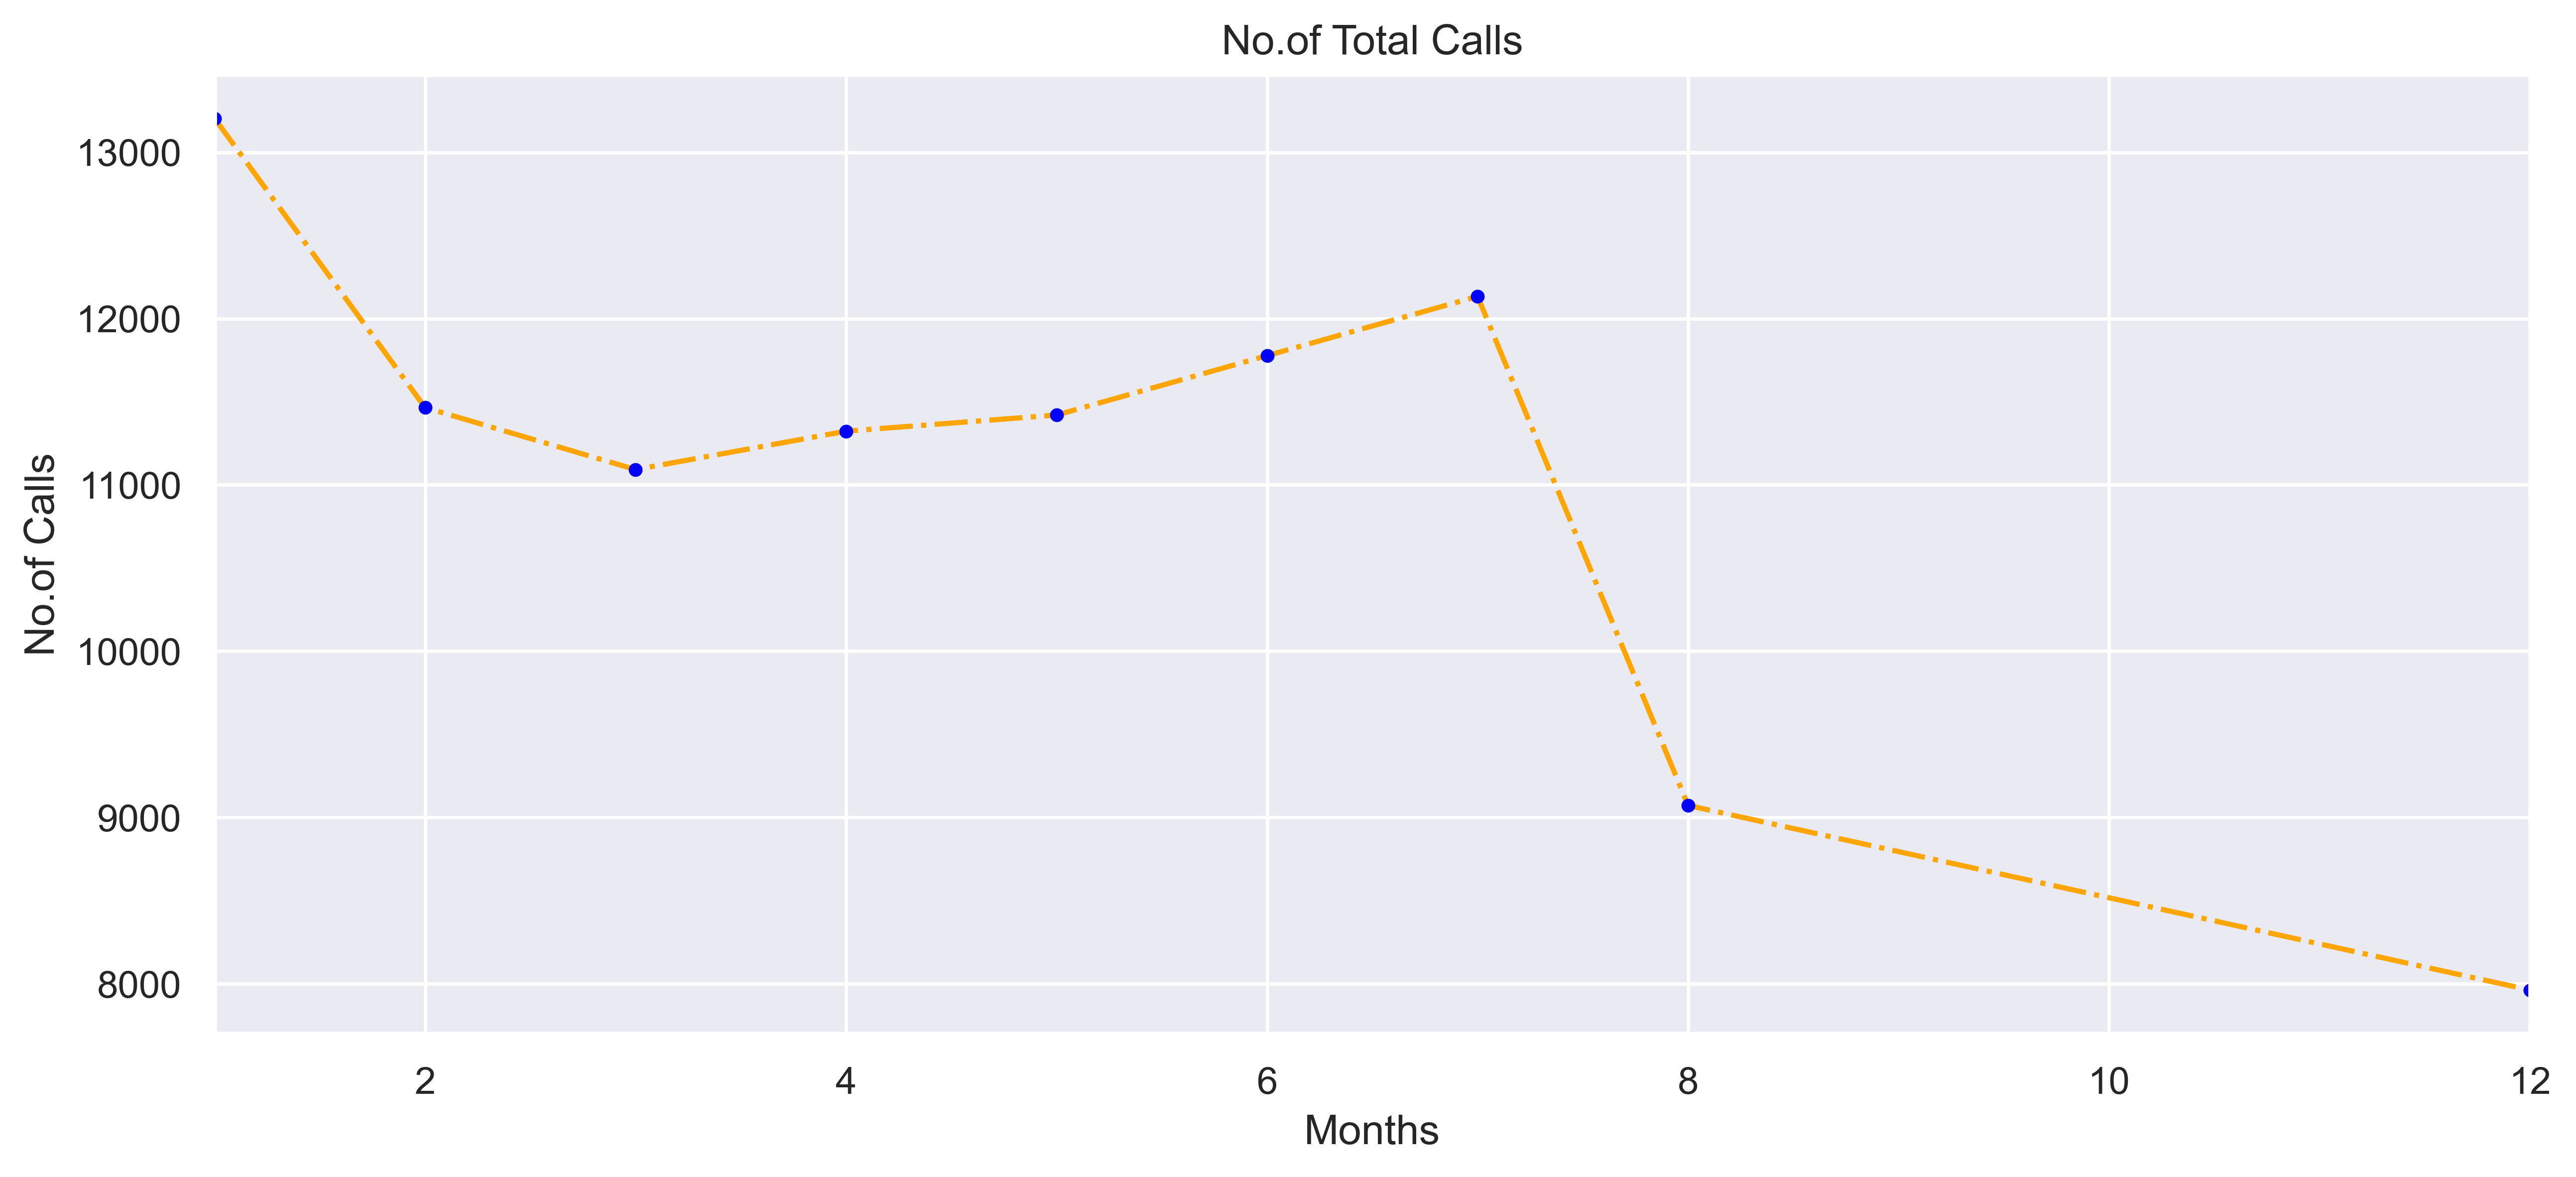

In [13]:
# Setting Coordinates:
XCOR = by_months.index
YCOR = by_months["twp"]

# Setting Frame
plt.figure(figsize=(12, 5), dpi=500)


# Setting Label
plt.title("No.of Total Calls")
plt.xlabel("Months")
plt.ylabel("No.of Calls")


plt.xlim(XCOR.min(), XCOR.max())

plt.plot(
    XCOR,
    YCOR,
    color="orange",
    marker=".",
    markerfacecolor="blue",
    markeredgecolor="blue",
    ls="-.",
)

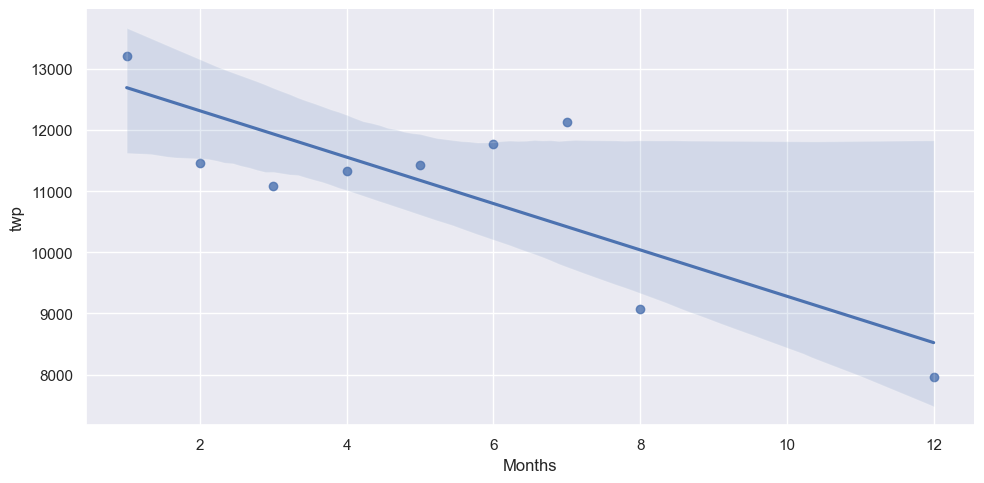

In [14]:
sns.lmplot(
    data=by_months.reset_index(),
    x="Months",
    y="twp",
    height=5,
    aspect=2,
)

##### Creating New column for getting the date


In [15]:
df["Date"] = df["timeStamp"].apply(lambda x: x.date())

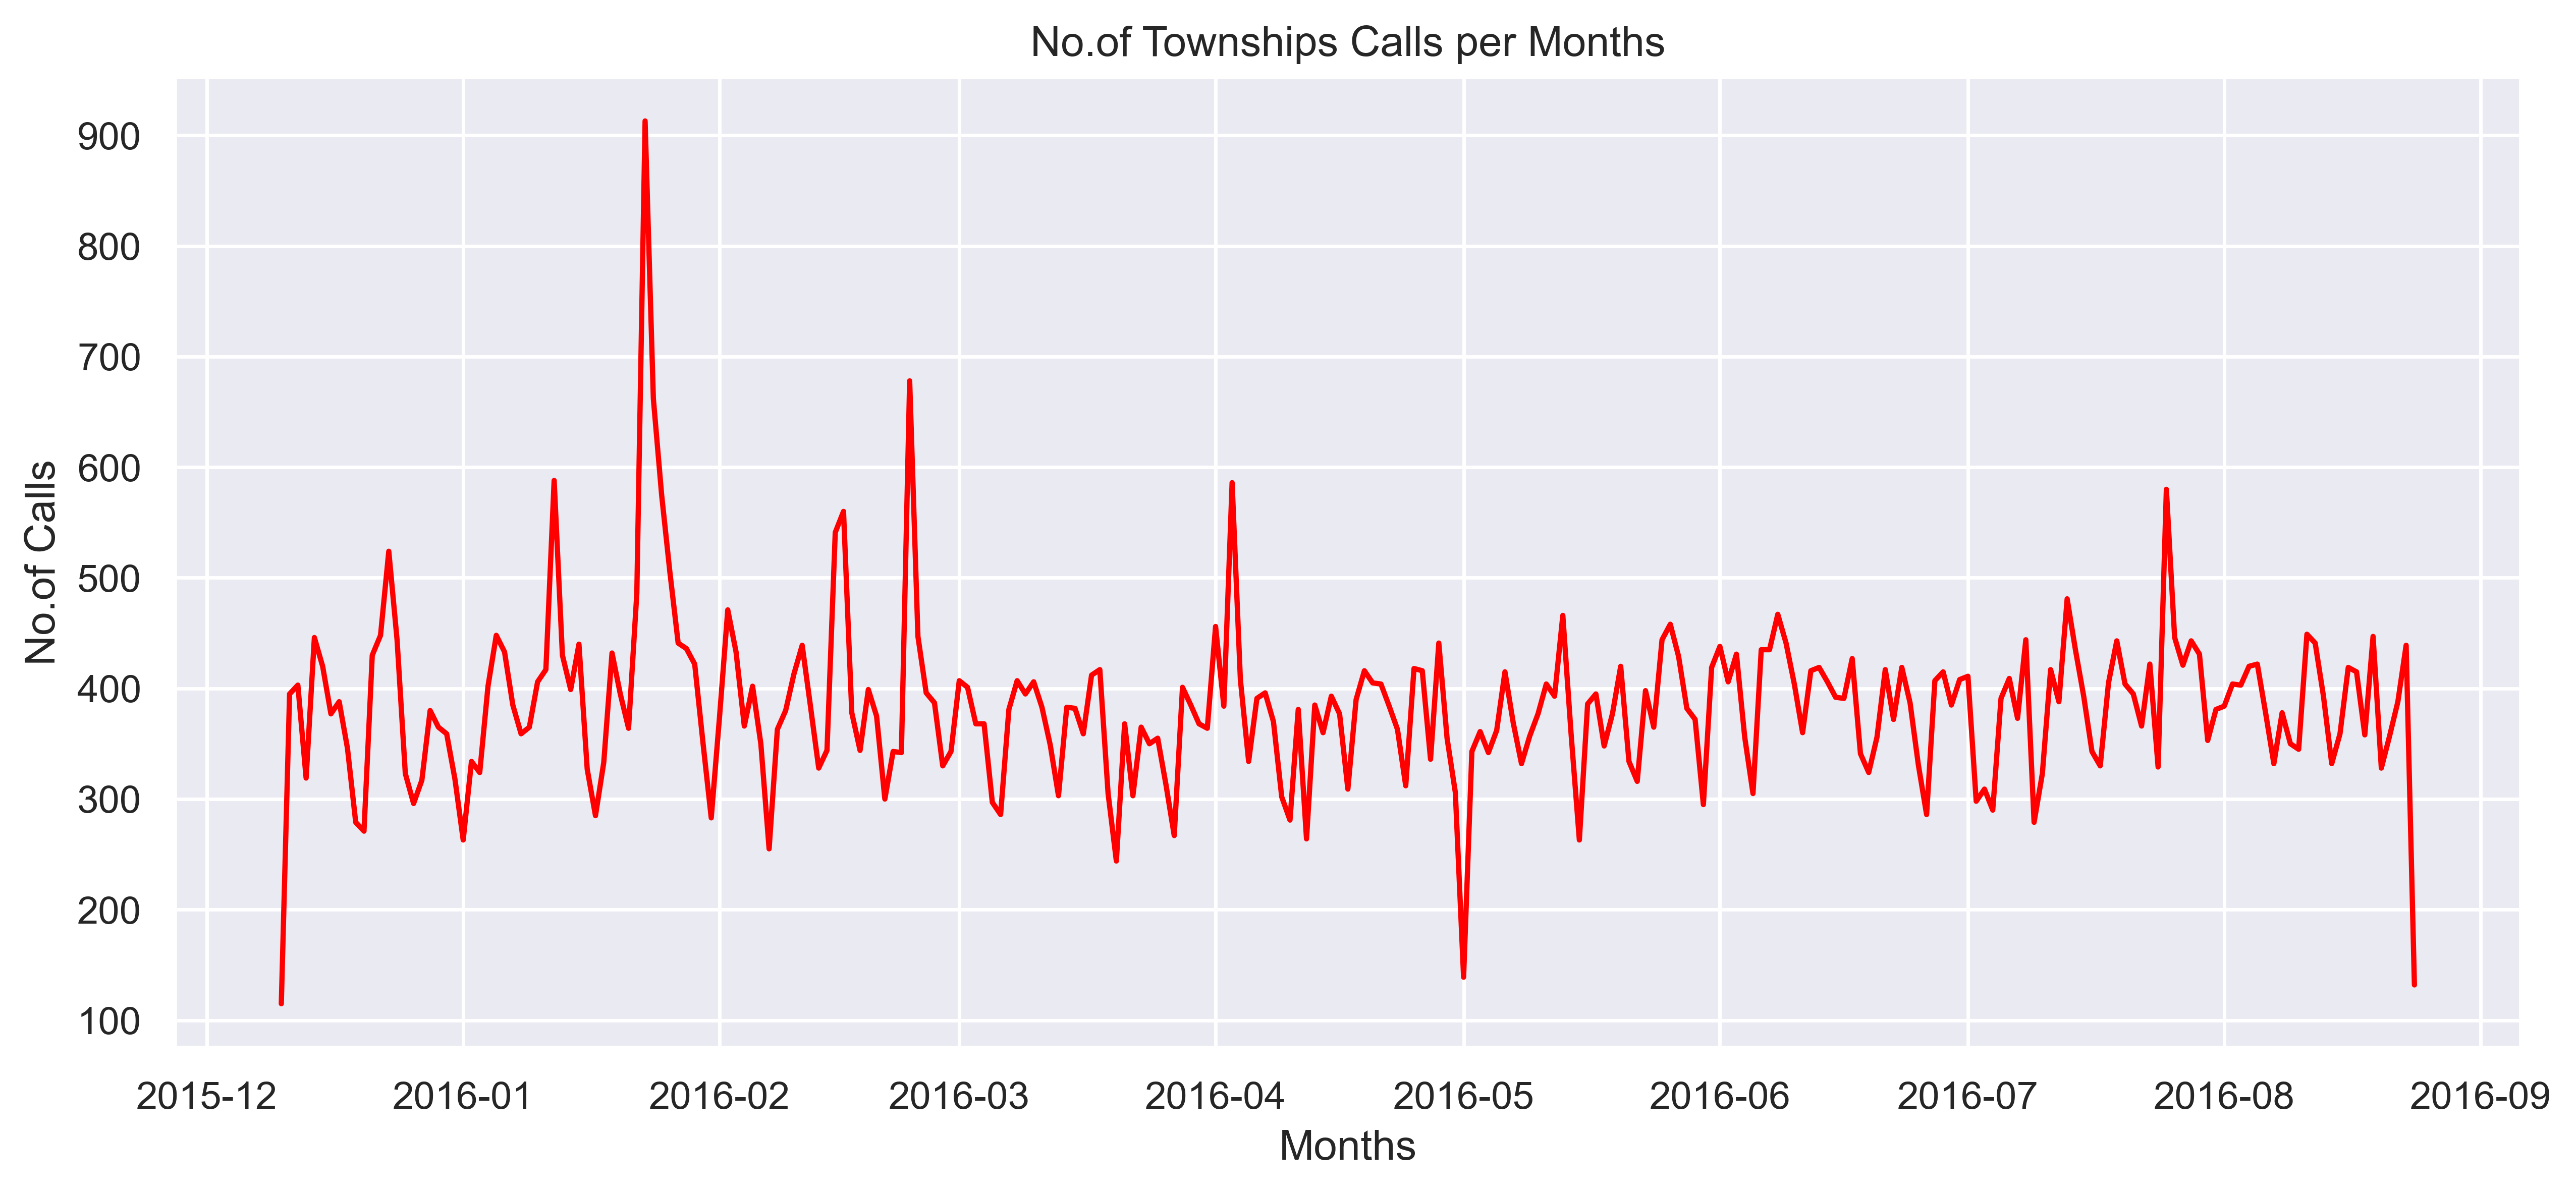

In [17]:
twp_count = df.groupby("Date").count()["twp"]

twp_count.head()

# Setting Coordinates:
XCOR = twp_count.index
YCOR = twp_count.values

# Setting Frame
plt.figure(figsize=(12, 5), dpi=500)

# Setting Label
plt.title("No.of Townships Calls per Months")
plt.xlabel("Months")
plt.ylabel("No.of Calls")

# Plotting:
plt.plot(
    XCOR,
    YCOR,
    color="red",
)

plt.show()